# Project 2: Similarity Matrix and Language Clustering
Submitted on November 10, 2025

NLP1000 S17
Group 12: 
| Member Name      | ID Number      |
| ------------- | ------------- |
| Alcantara, Van Asher | 12340898 |
| Aragon, Enrique | 12227811 |
| Clavano, Angelica (Jack) | 12206245 |
| Lozada, Job | 12307246 |

## Table of Contents
0. Libraries
1. Data Sourcing & Pre-processing
2. Similarity Matrix
3. Dendrogram
4. Interpretation of the Matrix & Dendrogram
5. Conclusion and Insights
6. Declaration of AI Usage

---

## Running this Notebook:
- Make sure you have at least Python 3.12.0 or 3.14.0 installed.
- To install the requirements, run `pip install -r requirements.txt` It has been updated for usage with `project2.ipynb`

---

## Folder Structure:
```
/nlp1000 --> root
└── /data
    └── lang.txt files --> raw webscraped data
    └── /cleaned
        └── (sentences)-lang-cleaned.txt --> cleaned sentence files in txt format
        └── lang-cleaned.txt --> cleaned verse files in txt format
└── /parallel-corpora --> parallel corpora (aligned) but in separate xlsx files
└── .gitignore
└── main.ipynb --> PROJECT 1 SUBMISSION containing documentation and source code
└── project2.ipynb --> PROJECT 2 SUBMISSION
└── removed.ipynb --> experimental code not part of the main submission
└── cleaned_sentences.ipynb --> cleaned sentence files in xlsx format - from data/cleaned/(sentences)-(lang)-cleaned.txt files
└── README.md --> contains the same information as this markdown block.
└── cleaned_verses.xlsx --> cleaned verse files in xlsx format - created when running the notebook from data/cleaned/(lang)-cleaned.txt
└── parallel_corpora.xlsx --> parallel corpora base file (unaligned) - created when running the notebook 
└── parallel_corpora_all.xlsx --> parallel corpora (aligned)
└── ai_declaration_project1.pdf --> AI declaration
└── ai_declaration_project2.pdf --> AI DECLARATION FOR PROJECT 2
└── steps.xlsx --> steps for regex present in divide_into_verses() and divide_into_sentences()
```

## **0. Libraries**

The following Python libraries/methods were used for this project. It is necessary to install the ones with attached comments through the CLI. 

**nltk** - used to tokenize the text, as well as to generate trigrams and their respective frequency counts

**nltk - TweetTokenizer** - specific tokenizer needed for the text

**pathlib - Path** - used to manipulate the current directory of the notebook for correct file pathfinding

**pandas** - standard data science library used for the creation of the dendrogram

**scipy - dendrogram, linkage** - used to perform hierarchical clustering and create the dendrogram

**matplotlib.pyplot** - used to display the dendrogram\


In [1]:
import nltk                 # pip install nltk
from pathlib import Path    # pip install pathlib
import pandas as pd         # pip install pandas
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

from nltk.tokenize import TweetTokenizer

The code below is just to create a list for iterating through our language files. If someone wishes to add or remove languages in their own recreation of this project, they can edit this list.

In [2]:
languages = ["spanish", "tagalog", "english", "hiligaynon", "bikol", "waray", "ilocano", "cebuano", "kapampangan", "pangasinense", "yakan", "ivatan", "tausug", "yami", "tuwali_ifugao", "masbateno"]

The following code block is commented out as this only needs to be run once. Once this has been run once, or if you already have these libraries installed, **DO NOT** run this code block again, as it will cause issues. Comment it out or run only the code blocks below it instead.

In [3]:
#needed for nltk, you can just run this once
'''
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('popular')'''

"\nnltk.download('punkt')\nnltk.download('punkt_tab')\nnltk.download('popular')"

## **1. Data Sources & Pre-processing**

### 1.1 Data Sourcing

For this project, we opted to use the cleaned-up text from the first project as our corpora, specifically the version split by sentences. Not only is it already preprocessed data, but it also reaches the requirement of 50,000 words per language corpora. Additionally, they are all translations of the same Bible books (Matthew, Mark, Luke, and John) from the Gospel of the New Testament. This will ensure that the generated trigrams and similarity matrix will properly reflect the relationships between each language.


### 1.2 Generating Trigrams with NLTK

For this project, we decided to generate **character trigrams** as our feature set to create the similarity matrix later on. Initially, we considered using each corpora's most common words as the primary criteria used in creating our similarity matrix. However, we decided against it as even minor spelling differences between functionally similar words would result in a mismatch. Character trigrams, on the other hand, seemed to be more indicative of repeating patterns or similarity between languages.

An important note is that we have intentionally replaced the whitespace characters that may show up in the trigrams with _ for visibility purposes. Since all instances of whitespace in the trigrams are replaced, this does not affect the resulting similarity matrix.

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

data_folder = Path("corpora")
output_folder = Path("all_trigrams")

for lang in languages:
    # define source and output
    source_file_path = data_folder / f"{lang}-corpora.txt"
    output_file_path = output_folder/f"{lang}-all-trigrams.txt"

    # if source doesn't exist skip
    if not source_file_path.exists() or source_file_path.stat().st_size == 0:
            print(f"Skipped: {source_file_path} (file does not exist or is empty)")
            # continue
    else:       
        # rewrite all the txts if it exists
        if output_file_path.exists():
            print(f"unlinking/deleting old files")
            output_file_path.unlink()

        # read input
        with source_file_path.open("r", errors="ignore", encoding="utf-8") as f:
            raw_sentences = f.read()

        # DO WHATEVER YOU WANT HERE
        # tokens = word_tokenize(raw_sentences) # split into words - DON'T DELETE THIS THANKS
        characters = [c for c in raw_sentences]

        # if you want to do it in words replace "characters" with "tokens"
        # unigrams = list(ngrams(characters, 1))
        # bigrams = list(ngrams(characters, 2))
        trigrams = list(ngrams(characters, 3))

        # save them to the file
        with output_file_path.open("w", encoding="utf-8") as f:
            f.write("Trigrams\n")
            for list_tuple in trigrams:
                # replace space with _ for readability and so the tab actually works in top 250
                cleaned = ( '_' if (isinstance(ch, str) and ch.isspace()) else str(ch) for ch in list_tuple )
                f.write("".join(cleaned) + "\n")
                # f.write(" ".join(map(str, list_tuple)) + "\n") - DONT DELETE THIS THANKS

        print(f"Cleaned and saved: {output_file_path}")


Cleaned and saved: all_trigrams\spanish-all-trigrams.txt
Cleaned and saved: all_trigrams\tagalog-all-trigrams.txt
Cleaned and saved: all_trigrams\english-all-trigrams.txt
Cleaned and saved: all_trigrams\hiligaynon-all-trigrams.txt
Cleaned and saved: all_trigrams\bikol-all-trigrams.txt
Cleaned and saved: all_trigrams\waray-all-trigrams.txt
Cleaned and saved: all_trigrams\ilocano-all-trigrams.txt
Cleaned and saved: all_trigrams\cebuano-all-trigrams.txt
Cleaned and saved: all_trigrams\kapampangan-all-trigrams.txt
Cleaned and saved: all_trigrams\pangasinense-all-trigrams.txt
Cleaned and saved: all_trigrams\yakan-all-trigrams.txt
Cleaned and saved: all_trigrams\ivatan-all-trigrams.txt
Cleaned and saved: all_trigrams\tausug-all-trigrams.txt
Cleaned and saved: all_trigrams\yami-all-trigrams.txt
Cleaned and saved: all_trigrams\tuwali_ifugao-all-trigrams.txt
Cleaned and saved: all_trigrams\masbateno-all-trigrams.txt


After generating the character trigrams found in each language's corpora, along with their respective frequencies, we used NLTK's most_common() method to generate files containing only the top 250 most common character trigrams per language. While we initially considered 1000 trigrams or more to account for the sheer size each corpora, we realized that the type of similarity we planned to use for the similarity matrix, the Dice coefficient, did not account for the frequency of each trigram. If we treated the most common character trigram with the same level of relevance as the 1000th most common character trigram, then the resulting similarity matrix may misrepresent how similar the languages actually are.

In [10]:
from collections import Counter
data_folder = Path("all_trigrams")
output_folder = Path("t250-trigrams")

for lang in languages:
    # define source and output
    source_file_path = data_folder / f"{lang}-all-trigrams.txt"
    output_file_path = output_folder/f"{lang}-t250.txt"

    # if source doesn't exist skip
    if not source_file_path.exists() or source_file_path.stat().st_size == 0:
            print(f"Skipped: {source_file_path} (file does not exist or is empty)")
            # continue
    else:       
        # rewrite all the txts if it exists
        if output_file_path.exists():
            print(f"unlinking/deleting old files")
            output_file_path.unlink()

        # read input
        with source_file_path.open("r", errors="ignore", encoding="utf-8") as f:
            next(f, None) # skip the first line bc it's just a title
            trigrams = [line.strip() for line in f if line.strip()]

        freq_counter = Counter(trigrams)
        top_250_trigrams = freq_counter.most_common(250)

        # save them to the file
        with output_file_path.open("w", encoding="utf-8") as f:
            f.write(f"{lang}top250\n") # f.write("Top 250\tFrequency\n")
            for trigram, count in top_250_trigrams:
                 f.write(f"{trigram} {count}\n") # f.write(f"{trigram}\t\t{count}\n")

        print(f"Cleaned and saved: {output_file_path}")
        

unlinking/deleting old files
Cleaned and saved: t250-trigrams\spanish-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\tagalog-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\english-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\hiligaynon-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\bikol-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\waray-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\ilocano-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\cebuano-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\kapampangan-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\pangasinense-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\yakan-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\ivatan-t250.txt
unlinking/deleting old files
Cleaned and saved:

After generating the top 250 character trigrams of each language, we manually imported each txt file into Google Sheets as a CSV in order to line them up with each other. The CSV created from this is what we will use as a basis for our similarity matrix.

The top 250 character trigrams per language can be found [here](https://docs.google.com/spreadsheets/d/13XduT75m-G1xUqucKRqv8CBZWuz_OuDsENqoi2Qua_w/edit?usp=sharing).

## EVERYTHING AFTER HERE WE NEED TO CHANGE I THINK

## 2. Similarity and Clustering / Dendrogram

Using the top 250 trigrams per language created in the previous section, we can now create the similarity matrix. As mentioned earlier, we decided to create the similarity matrix using the **Dice Coefficient** to compute for similarity. The formula for dice coefficient is as follows:

 $$ Dice Coefficient =  \frac{2 * |LanguageA ∩ LanguageB|}{|LanguageA| + |LanguageB|}$$

where LanguageA / B is the set of that language's character trigrams.

In [ ]:
data_folder = Path("p2data")

# import the top 250 trigrams sheet
top250csv_filepath = data_folder / "top250trigrams.csv"
top250_df = pd.read_csv(top250csv_filepath)

# set the cols to s1, s2, s3 etc.
cols = list(top250_df.columns)
top250_df.columns = [f"s{i+1}" for i in range(top250_df.shape[1])]
top250_df.head()

,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16
0,an_,an_,_a_,ng_,ti_,_ka,ng_,an_,in_,_si,an_,_th,ng_,_de,ng_,an_
1,_na,_na,o_a,ang,iti,an_,ing,ay_,iya,si_,_sa,the,_sa,os_,ang,nga
2,_sa,NaN,na_,sa_,_ti,_na,ang,_na,an_,an_,_na,he_,ang,que,_sa,_ng
3,na_,ya_,_na,_sa,_a_,_a_,an_,_to,_ma,_pa,ng_,nd_,ga_,ue_,_na,_ha
4,_ka,_di,an_,_ka,_it,a_a,_ka,_si,_si,ang,_ka,_an,sa_,de_,sa_,ga_


After importing the CSV file containing the character trigrams of each language, each language is converted into their own series before converted into a set. This conversion allows us to use Pandas' intersection() method to find the set of intersecting trigrams between any two languages. The cardinality of the result of this is used in the computation of the Dice coefficient between each language.

In [ ]:
languages = ["spanish", "tagalog", "english", "hiligaynon", "bikol", "waray", "ilocano", "cebuano", "kapampangan", "pangasinense", "yakan", "ivatan", "tausug", "yami", "tuwali_ifugao", "masbateno"]
corpus = []
for lang in languages:
    # Repeat each trigram by its frequency count
    trigrams = ' '.join([trigram] * count for trigram, count in lang_top250)
    corpus.append(trigrams)


In [ ]:
# divide each one into a series, using the original languages order
languages = ["spanish", "tagalog", "english", "hiligaynon", "bikol", "waray", "ilocano", "cebuano", "kapampangan", "pangasinense", "yakan", "ivatan", "tausug", "yami", "tuwali_ifugao", "masbateno"]

series_list = [top250_df.iloc[:, i] for i in range(top250_df.shape[1])]

spanish_df = series_list[0] 
tagalog_df = series_list[1]
english_df = series_list[2]
hiligaynon_df = series_list[3]
bikol_df = series_list[4]
waray_df = series_list[5]
ilocano_df = series_list[6]
cebuano_df  = series_list[7]
kapampangan_df = series_list[8]
pangasinense_df = series_list[9]
yakan_df = series_list[10]
ivatan_df = series_list[11]
tausug_df = series_list[12]
yami_df = series_list[13]
tuwali_ifugao_df = series_list[14]
masbateno_df = series_list[15]

# put them here just so its easier for everyone instead of doing series_list[i] a lot
all1000series = [spanish_df, tagalog_df, english_df, hiligaynon_df, bikol_df, waray_df, ilocano_df, cebuano_df, kapampangan_df, pangasinense_df, yakan_df, ivatan_df, tausug_df, yami_df, tuwali_ifugao_df, masbateno_df]

for i in range (16):
    for j in range(16):
        intersection = len(set(series_list[i]).intersection(set(series_list[j])))
        dice_coeff = (2 * intersection) / (len(set(series_list[i])) + len(set(series_list[j])))
        print("%.3f" %dice_coeff, "", end = "")
    print("\n", end="")

1.000 0.384 0.384 0.656 0.520 0.500 0.480 0.508 0.492 0.432 0.720 0.128 0.740 0.200 0.592 0.704 
0.384 1.000 0.260 0.364 0.432 0.340 0.424 0.396 0.420 0.344 0.388 0.140 0.372 0.132 0.344 0.396 
0.384 0.260 1.000 0.384 0.372 0.568 0.332 0.412 0.312 0.276 0.376 0.120 0.368 0.172 0.352 0.376 
0.656 0.364 0.384 1.000 0.456 0.432 0.456 0.460 0.452 0.384 0.632 0.136 0.740 0.176 0.592 0.636 
0.520 0.432 0.372 0.456 1.000 0.444 0.472 0.544 0.388 0.376 0.496 0.152 0.496 0.184 0.472 0.500 
0.500 0.340 0.568 0.432 0.444 1.000 0.376 0.476 0.332 0.300 0.484 0.160 0.452 0.224 0.384 0.460 
0.480 0.424 0.332 0.456 0.472 0.376 1.000 0.520 0.492 0.424 0.484 0.148 0.460 0.184 0.528 0.444 
0.508 0.396 0.412 0.460 0.544 0.476 0.520 1.000 0.420 0.356 0.508 0.208 0.496 0.208 0.488 0.504 
0.492 0.420 0.312 0.452 0.388 0.332 0.492 0.420 1.000 0.508 0.464 0.104 0.460 0.148 0.468 0.500 
0.432 0.344 0.276 0.384 0.376 0.300 0.424 0.356 0.508 1.000 0.424 0.168 0.400 0.188 0.412 0.384 
0.720 0.388 0.376 0.632 0.496 

Once we're given the results of the similarity matrix, we opted to directly export the output text as a txt file, then load it into Google Sheets using whitespace as the delimiter to export it as a CSV. While it is possible to perform this action using Python libraries, we wanted more strict control on how the resulting similarity matrix CSV would end up looking. Additionally, it may be difficult to modify the code used to generate the CSV if one wished to add or remove languages. 

Attached below is a screenshot of the final similarity matrix. This is what will be used to generate the dendrogram later on.
![FINAL-SIMILARITY-MATRIX](./p2data/sim-matrix-final.png)

## 3. Creating the Dendrogram

After completing our similarity matrix, we used Matplotlib and imports from the Scipy library in order to create the dendrogram / language tree. While we initially intended on trying Weka for this process, as demonstrated in class, we eventually decided to use Python as it was more familiar to us. 

However, we cannot directly convert the similarity matrix into a dendrogram. Before that, we have to process it into a distance matrix, as dendrograms represent the measure of distance between languages, rather than how similar they are. Processing the similarity matrix is actually very straightforward. Since Pandas allows simple DataFrame-wide operations, we simply assign the operation of ```1 - sim_matrix``` into the variable ```dist_matrix```. 

Afterwards, we use the linkage method to perform hierarchical clustering, selecting 'ward' as the method to minimize variance after each clustering cycle. Afterwards, we create a dendrogram given the hierarchical clustering and display the final result.

C:\Users\Coco\AppData\Local\Temp\ipykernel_1132\1445896976.py:9: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  hc = linkage(dist_matrix, method='ward')


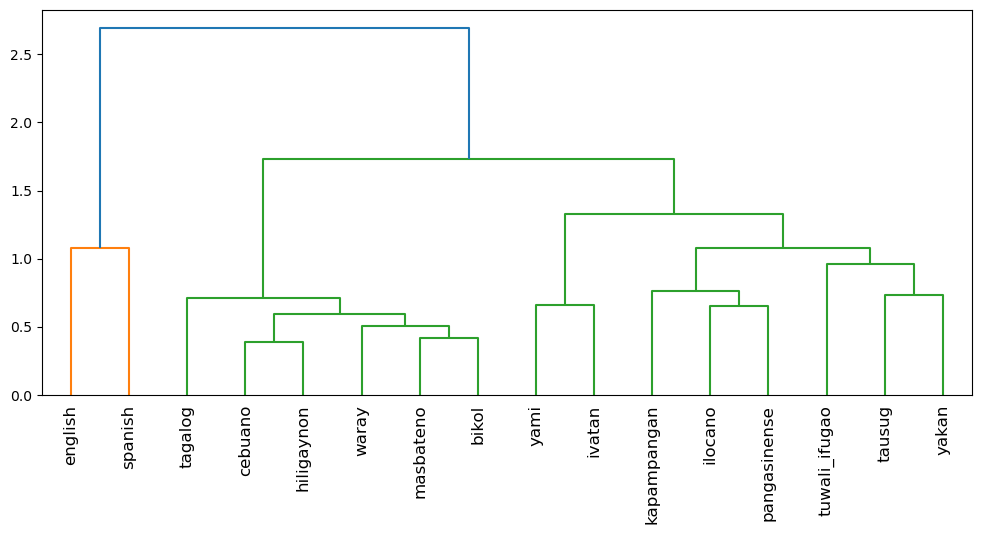

In [ ]:
csv_fp = data_folder / "250.csv"
#importing the CSV, index_col = 0 basically tells Pandas to ignore the first column for any operations
sim_matrix = pd.read_csv(csv_fp, index_col=0)

#converting sim_matrix into a distance matrix for hierarchical clustering
dist_matrix = 1 - sim_matrix

# hierarchical clustering
hc = linkage(dist_matrix, method='ward')

#make a dendrogram
plt.figure(figsize=(12, 5))
dendrogram(hc, labels=dist_matrix.columns, leaf_rotation=90)
plt.show()

## 4. Interpretation of the Matrix & Dendrogram

### 4.1 Major Clusters A and B: Grouped by distance

![dendrogram_groupa_groupb](dendrogram_groupa_groupb.png)

The major clusters are the easiest to explain. They are grouped by distance from each other. 

#### A English, Spanish: Languages from the West
English is an Indo-European language [(Britannica)](https://www.britannica.com/topic/English-language) and Spanish is a Romance language, also within the Indo-European langauge. [(Britannica)](https://www.britannica.com/topic/Spanish-language)

#### B Cebuano, Hiligaynon/Ilonggo, Waray, Masbateno, Bikol, Yami, Ivatan, Kapampangan, Ilocano, Pangasinense, Tuwali-Ifugao, Tausug, Yakan: Languages from the East
Cebuano is a language in the Philippines belonging to the Austronesian language family. [(Ethnologue)](https://www.ethnologue.com/language/ceb/) Hiligaynon, Waray, Masbateno, Bikol (Macrolanguage), Ivatan, Kapampangan, Ilocano, Pangasinense, Tuwali-Ifugao, Tausug, and Yakan are also within the Philippines and in the Austronesian language family.

Yami originates from Taiwan, but is still part of the Austronesian language family like the previous ones. [(Ethnologue)](https://www.ethnologue.com/language/tao/)

### 4.2 Sub Clusters 

![dendrogram_groupa_groupb_sub1](dendrogram_groupa_groupb_sub1.png)

This section begins breaking down the subgroups and providing context as to why they are grouped as such.

#### A1 English vs A2 Spanish (individual differences)
Spanish traces its roots from Rome, developing from Vulgar Latin. It originated from the Iberian Peninsula. [(Wyland, 2025)](https://online.utpb.edu/about-us/articles/spanish/the-history-of-spanish-language-from-latin-roots-to-a-global-reach/) [(Tobian, 2024)](https://tobian-languageschool.com/spanish-vs-english-language-key-differences-history-and-fascinating-comparisons/) English is a Germanic language [(Tobian, 2024)](https://tobian-languageschool.com/spanish-vs-english-language-key-differences-history-and-fascinating-comparisons/) from the continent of Britain. [(Merriam-Webster)](https://www.merriam-webster.com/help/faq-history).

#### B1 Tagalog, Cebuano, Hiligaynon/Ilonggo, Waray/Waray-Waray, Masbateno/Masbatenyo/Masbateño, Bikol: Major Languages Around The Philippines

According to [Reid](https://scholarspace.manoa.hawaii.edu/items/2180a11e-54a4-44a9-b47e-3d759306c2fa), all Philippine Languages are within the Malayo-Polenesian group of the Austronesian language family. In the same paper, Reid mentions that Tagalog, Sebuano/Cebuano, Hiligaynon, Bikol, Samar-Leyte, Kapampangan, Pangasinan, Maranao, Ilokano/Ilocano, and Magindanao are regarded as major languages in the Philippines. (Reid, 2005) 

The Central Philippines subgroup contains languages like Tagalog, Mamanwa, and some Bikol, Bisayan, and Mansakan languages. Tagalog, Cebuano, Hiligaynon/Ilonggo, Waray, and Bikol are within this group. (Zorc et. al) This leaves Waray and Masbateno. These languages are within the Central Bisayan subgroup and are regarded as major languages.

- Tagalog is in its own language subgroup, according to [(Zorc et. al)](httpszorcnetpublications142a-submitted=Philippines_Historical_Chapter[Zorc-Lobel-Hall].pdf) It is the most widely studied Philippine language and chosen as a National Language.
- Cebuano, Ilocano, and Hiligaynon are regional trade languages. (Reid, 2005) 
    - Ilocano is a major trade language of most of northern Luzon and found in western Mindanao. (Zorc et. al.)
- Cebuano is spoken in the Visayan area of Central Philippines and southern Mindanao. (Reid, 2005)
    - Ilocano is spoken in southern Mindanao. (Reid, 2005)
    - Ilocano is the "main language of trade and wider communication" in northern Luzon. (Reid, 2005)
- Hiligaynon, also known as Ilonggo [(Zorc, 2001)](https://ia800207.us.archive.org/9/items/rosettaproject_hil_detail-1/rosettaproject_hil_detail-1.pdf), is a major trade language in western Visayas.
- Kapampangan is in the Central Luzon subgroup. (Zorc et. al.)

Therefore, the B1 subgroup (in our dendrogram) may be regarded as major languages compared to others, as they possess broader geographical distribution, stronger linguistic influence, and significantly greater availability of research and resources. Notably, however, Tagalog continues to dominate the list.

#### B2 Yami, Ivatan, Kapampangan, Ilocano, Pangasinense, Tuwali-Ifugao, Tausug, Yakan: Lesser-covered or Indigenous Languages

Ethnologue states that Yami is an endangered indigenous language in Taiwan. Taiwan is located north of the Philippines, and has a population less than 10,000. The same resource also mentions that Ivatan is a stable indigenous language, with a population of 10,000-1m people. It is spoken in the Batanes Islands, in Mindanao, and Southern Taiwan. Ivatan was primarily a spoken language and is seldom used in written form. [(Omniglot)](https://www.omniglot.com/writing/ivatan.htm) [(EverythingExplained)](https://everything.explained.today/Ivatan_language/) It is to note that Yami and Ivatan are closely related geographically, and its division is covered later in this notebook.

Kapampangan has a population of more than 1 million [(Ethnologue)](https://www.ethnologue.com/language/pam/) and is spoken in Central Luzon. [(SinaunangPanahon)](https://sinaunangpanahon.com/kapampangan-language-of-the-philippines/) Reading material for this language is limited. [(Forman, 1971)](https://scholarspace.manoa.hawaii.edu/server/api/core/bitstreams/643e6458-31d8-4e86-99d7-c001d804b510/content) With a population of around 1m [(Ethnologue)](https://www.ethnologue.com/language/ilo/), Ilocano is an indigenous language, spoken in places such as the Apayao province in the Cordillera Administrative Region. [(Arce-daet, 2024)](https://garph.co.uk/IJARMSS/Nov2024/G-3093.pdf) In a similar area, Pangasinense/Pangasinan is also within the Southern Cordilleran langauge subgroup. (Zorc et. al.) According to [Anderson & Anderson.](https://www.jstor.org/stable/42633901), there is very little media coverage with this language. 

Tuwali-Ifugao, or Tuwali, is mainly spoken in the Southern Ifugao Province, Kiangan. As [Taleon](https://www.researchgate.net/publication/344170392_A_Phonological_Sketch_of_Tuwali_Ifugao) states, Kiangan is the oldest town in the province, indicative that it may have been one of the earliest centers of Ifugao culture and linguistic development. Many people in the population have learned it as their first language. It is also in the Central Cordilleran language subgroup. (Zorc et. al.) The Tausug language is spoken by the indigenous Tausug people in East Mindanao. The rise of the English language has affected the preservation of Tausug. [(Tahil et. al)](https://www.researchgate.net/publication/376075255_Preserving_and_Nurturing_Tausug_Language_The_Bahasa_Sug_Mobile_Learning_Application_Tool_for_Enhancing_Mother_Tongue_Development_for_Toddlers) 

Finally, Yakan is a stable indigenous language [(Ethnologue)](https://www.ethnologue.com/language/yka/) spoken by the Yakan tribe in the Sulu Archipelago in Mindanao. [(Defense Language Institute)](https://fieldsupport.dliflc.edu/products/yakan/yn_co/Yakan.pdf) According to the same paper, very few Yakan are literate in their own written language. 

The B2 group (in our dendrogram) represents a cluster of indigenous Philippine languages that remain underrepresented in linguistic research, characterized by limited documentation, minimal media exposure, and scarce modern linguistic resources.

### 4.3 Deeper into the subclusters

![dendrogram_groupa_groupb_sub2](dendrogram_groupa_groupb_sub2.png)

This section breaks down B1 and B2 into further subgroups, focusing on B1 and B2. B2 has two subclusters, but Yami and Ivatan have already been divided into B2a and B2b.

#### B1a Tagalog: The National Language
As mentioned previously, Tagalog has its own language subgroup and is the most widely-studied. As it takes its place as the National Language, it is being taught in schools around the country. (Zorc et. al.) This language is spoken mostly in Manila, Central Luzon, and Palawan. [(Malabonga, 2009)](https://www.researchgate.net/publication/319401768_Heritage_Voices_Language-Tagalog)

#### B1b Cebuano, Hiligaynon/Ilonggo, Waray/Waray-Waray, Masbateno/Masbatenyo/Masbateño, Bikol: Languages present in Visayas to Mindanao

According to this [Informational Report by DeFraga](https://www.ritell.org/Resources/Documents/language%20project/Cebuano.pdf), Cebuano is spoken in Cebu, Bohol, Negros Oriental, Leyte, Samar, Negros Occidental, Biliran Islands, Masbate Island, and Mindanao. These are the lower half of the Philippines, starting in Visayas. In Zorc et. al's paper, Cebuano is in the Bisayan language subgroup, but contains its own Cebuano branch as it has numerous dialects across the central Visayan/Bisayan Islands.

Hiligaynon, Waray, and Masbateno are also within the Bisayan language subgroup, but within the Central Bisayan/Visayan branch. (Zorc et. al.) Hiligaynon is spoken in Iloilo, Negros Occidental, Capiz, Guimaras, and some parts of Mindanao. (Reid, 2005) [(Besonia, 2022)](https://www.researchgate.net/publication/364154830_International_Journal_of_Multidisciplinary_Approach_and_Studies_The_Death_of_Hiligaynon_Terminologies_in_the_Coastal_Community_in_Northern_Iloilo_Philippines) These provinces, except Mindanao are provinces in Western Visayas. Waray is spoken in the Central and Northern part of Eastern Samar, and some documents have been written by those who were born in Tacloban. [(Madeja et. al., 2017)](https://scholar.google.com/citations?view_op=view_citation&hl=en&user=NNc6YiQAAAAJ&citation_for_view=NNc6YiQAAAAJ:UeHWp8X0CEIC) Masbateno is spoken in Masbate in the Bicol Region, but is still regarded as Visayan/Bisayan. [(Mabuan et. al., 2022)](https://aclanthology.org/2022.paclic-1.32/) Bikol, on the other hand, has its own subgroup. The Bikol subgroup contains languages within the Bicol region. (Zorc et. al.) It is to note that the Bicol region is in Region V, which is in the lower half of Luzon.

Together, the languages in this subgroup form a cluster of Bisayan languages, whilst Tagalog is a language mostly spoken in Luzon, but is taught around the Philippines. Their overlapping geographic distribution across the central and southern islands of the Philippines underscore their close relationship.

#### Yami vs B2b Ivatan (individual differences)

Yami's place can be explained by [Reid's paper](https://scholarspace.manoa.hawaii.edu/items/2180a11e-54a4-44a9-b47e-3d759306c2fa), stating that Austronesian speakers arrived in Northern Philippines from Taiwan at the beginning of the migrations. This could explain why Yami, an endangered indigenous language of Taiwan, was also grouped and spoken in parts of the Philippines. According to [Yang and Rau](https://www.elararchive.org/dk0110/), Yami is a Philippine Batanic language and belongs to the Ivatan or Bashiic language group. 

As mentioned previously, Yami belongs to the Ivatan/Bashiic language group, but it has been separated from Ivatan. The first reason may be because it's mainly a language in Taiwan. [(Ethnologue)](https://www.ethnologue.com/language/tao/) Ivatan is a stable indigenous language in the Philippines and is more widely used compared to Yami. [(Ethnologue)](https://www.ethnologue.com/language/ivv/).

#### B2c Pangasinense, Tuwali-Ifugao, Tausug, Yakan: Batanic subgroup of the Philippine languages

Pangasinense is a major language of north-central Luzon [Anderson & Anderson] (http://www2.hawaii.edu/~vanderso/Pangasinan.pdf) while also belonging to the Southern Cordillera Group. Tuwali-Ifugao is part of the neighboring Central Cordilleran subgroup. Both of these languages are branches of the Northern Luzon macrogroup [Zorc et. al] (httpszorcnetpublications142a-submitted=Philippines_Historical_Chapter[Zorc-Lobel-Hall].pdf). Conversely, Tausug is a member of the Southern Bisayan subgroup, placing it within the larger Greater Central Philippine macrogroup. Yakan is excluded from the Philippine macrogroup altogether, belonging instead to the Sama-Bajaw languages which subgroup with Malagasy in the Greater Barito subgroup [Zorc et. al] (httpszorcnetpublications142a-submitted=Philippines_Historical_Chapter[Zorc-Lobel-Hall].pdf). While these languages are unlikely to reflect a true genetic subgroup, a possible reason for these languages being under the same group is due to axis relationships or borrowing across genetic boundaries due to social or trade networks. This could also be due to other non-genetic factors like linguistic contact and words shared from a very ancient ancestor language [Zorc et. al] (httpszorcnetpublications142a-submitted=Philippines_Historical_Chapter[Zorc-Lobel-Hall].pdf).

In comparison to Yami, it is separated to the four aforementioned languages primarily because, as mentioned earlier, it belongs to the Batanic subgroup of the Philippine languages and is the only language spoken outside of the Philippines, making it a geographical location difference.

### 4.4 Even Deeper

Here, we look even deeper. Those that have already been covered are greyed-out.

![dendrogram_groupa_groupb_sub3](dendrogram_groupa_groupb_sub3_v3.png)

#### B1ba Cebuano, Hiligaynon/Ilonggo: Regional Trade Languages from Visayas and Mindanao
According to Reid, both Cebuano and Hiligaynon are regional trade languages. Cebuano is mostly used not only in the Visayan part of the Philippines, but also spoken in Mindanao. Hiligaynon, on the other hand, is spoken in Southern Mindanao. (Reid, 2005) In a study conducted on the dialectal influence of these languages, students were found to have similar pronunciations when speaking in English, such as the voiceless /th/ not being present when they say the English word “think,” causing them to pronounce them as “tink.” [(Pardeno, 2023)](https://ijisrt.com/influence-of-hiligaynon-and-cebuanovisayan-in-the-englishspeaking-proficiency-of-college-students)

##### Cebuano vs Hiligaynon/Ilonggo
In a study that measured the proficiency of Hiligaynon-speaking students in Cebuano vocabulary, 100% of students were able to understand the Cebuano “nalimut.” (forgot). “Muabut” in Cebuano was equivalent to “mag-abot” in Hiligaynon. [(Emoy, 2022)](https://etcor.org/storage/iJOINED/Vol.%20I(2),%209-15.pdf) This shows that Hiligaynon-speakers may be able to understand some Cebuano. Although Cebuano and Hiligaynon are closely related as spoken dialects and share words, these words have different meanings according to the context. [(Cadigal et. al)](https://ejournals.ph/article.php?id=14043) For example, “Dula” may mean “lost” in Hiligaynon, but would mean “play” in Bisaya/Cebuano. “Karun” in Hiligaynon means “later,” but in Cebuano it means “now.” [(Xilium)](https://xillium.ph/ay-ambot-indi-ko-ka-inchindi/)


#### B1bb Waray/Waray-Waray, Masbateno/Masbatenyo/Masbateño, Bikol: Grouped by Proximity
Again, according to Zorc et al., these three languages are grouped together due to being spoken within proximity of each other. While Waray and Masbateno are considered to be a part of the Central Bisayan subgroup of languages, examining a map of the Philippines reveals that Samar and Masbate, where Waray and Masbateno are commonly spoken, are close to the Bicol region geographically. According to the Global Recordings Network, Waray and Bikol share more similarities to each other linguistically than Waray and Cebuano do.

#### B2ca Kapampangan vs B2cb Ilocano, Pangasinense
Lastly, the difference between these three languages primarily seems to lie in standard geographical proximity, similar to most other clusters. While there are shared similarities between the three, they ultimately differ enough to cluster into their own languages.

### 4.5 The Deepest

These are the deepest clusters of languages in our dendrogram. Again, those that have already been covered are greyed-out.

![dendrogram_groupa_groupb_sub4](dendrogram_groupa_groupb_sub4.png)

#### B1bb1 Waray/Waray-Waray
As mentioned previously, Waray is also separated from Bikol in terms of sub-groups, which is why it is split off from Masbateno and Bikol in the deepest cluster.

#### B2bb2 Masbateno/Masbatenyo/Masbateño, Bikol
According to [Zorc et. al,](httpszorcnetpublications142a-submitted=Philippines_Historical_Chapter[Zorc-Lobel-Hall].pdf), Masbateno is native to the Bikol region, but not included in the Bikol language subgroup.

#### B2cb1 Ilocano vs B2cb2 Pangasinense (individual differences)
Despite the relative geographical differences between Pangasinese and Ilocano, the two are still related due to migration. According to Anderson & Anderson (2007), there was a large number of Ilocanos who moved to Pangasinan during the 19th century, and were able to establish business, livelihoods, and even gain political power in the region. This can perhaps explain the close relations between the languages, but still have enough differences to warrant separating them into B2cb1 and B2cb2, deep into the language clusters.

#### B2ce1 Tausug vs B2ce2 Yakan (individual differences)
In the deepest clusters in B2ce are Tausug and Yakan, which both represent two major indigenous ethnolinguistic groups of Muslim Mindanao, sharing a culture and religious identity that potentially explains a close relationship that would warrant clustering them at the lowest levels. Their subtle differences may be attributed to the groups emerging at different times and immigration. According to a 1972 paper by Carol H. Molony, "A Chronology of the Sulu Region" that  appeared in the Borneo Research Bulletin, the ancestors of the Yakan people were already long in the archipelago before the Tausug, who likely emerged a year later due to immigration.


## 5. Conclusion & Insights

There was a long search for references, but we have reached the end. As seen in 4.1, the major divisions between these languages are by distance. This is supported by our initial list of languages that were selected in Project 1. We selected English and Spanish and deliberately searched for languages spoken around the Philippines, then added those to our list of corpora. 

While we believe that our final dendrogram sufficiently reflects the relationships between the 16 languages chosen, there are also some limitations. First of all, we believe that using the Bible as a source for our corpora, while useful for working with a more standardized version of each language, may not reflect updated speech trends or patterns. Additionally, when creating our similarity matrix, we opted to use the Dice coefficient, which does not take the frequency of the trigrams into account. While we compensated for this by using only the top 250 character trigrams from each language to maintain that each trigram was linguistically relevant, future tests with a more robust feature set and measure of similarity may give more accurate results.

We have observed that the resources were scattered amongst various archives and dates back to the early 2010s down to the 1960s. Therefore, we would like to recommend more researchers to cover the different languages and dialects of the Philippines. The coverage of these languages are important to our Philippine history and for the longevity and preservation of these languages. Furthermore, the inclusion of underrepresented and endangered dialects would provide a more accurate reflection of the linguistic diversity within the region. 

A number of these languages are derived from other languages in our corpora. As language continues to evolve, continuous updating of corpora and sharing of findings will greatly contribute to sustaining research momentum in this field of NLP, and of the study of Philippine languages.

## 6. Declaration of AI Usage

NLP1000 S17 Project 2
**Group 12: AI Declaration**
| Name | ID number | 
| --- | --- |
| Van Asher Alcantara | 12340898 | 
| Enrique Miguel M. Aragon | 12227811 | 
| Angelica Therese Clavano (Jack) | 12206245 | 
| Job Lozada | 12307246 | 

**Declaration of AI usage: Van Asher Alcantara**


I used ChatGPT for paraphrasing and grammar checking some parts of the writeup for this project.
**Extent of use:** Minimal – used only for grammar/spell check/definition.
**Prompts and Answers:**
Prompt: define shared vocabulary retention
ChatGPT:
**Shared vocabulary retention** refers to the ability of a group of people (such as members of a community, team, or culture) to **maintain and consistently use a common set of words, phrases, or terminologies** over time.
In other words, it describes **how well a group preserves its common linguistic repertoire**—the shared meanings and terms that allow members to communicate effectively and understand each other.
Here’s how it breaks down:
* **“Shared vocabulary”** means the set of words or expressions known and used by members of a particular group.
* **“Retention”** means keeping or maintaining something over time.
So, **shared vocabulary retention** can be defined as:
*The sustained use and preservation of a common set of words or terms within a community or group, ensuring continued mutual understanding and communication coherence over time.*
**Explanation**:
AI is very helpful when it comes to paraphrasing and finding definitions of uncommon words to possibly replace them with simpler terms. Additionally, it can also give suggestions on how to write after given a context and setting.

---

**Declaration of AI usage: Enrique Aragon**


I used Deepseek to verify my knowledge and understanding of how to create a dendrogram after finishing the similarity matrix, since the last language tree I created was with Weka, rather than Python.
**Extent of use:** Minimal – used for knowledge verification
**Prompts and Answers:**
Prompt: The similarity matrix is already generated using dice coefficients. Do I still convert it into a distance matrix to make a dendrogram?
Deepseek:
**Yes, for Dice coefficient you still need distance conversion:**
Dice coefficient = similarity (0 = no overlap, 1 = identical)
Use:
distance = 1 - Dice_coefficient
So:
* Dice = 1 → distance = 0 (identical languages)
* Dice = 0 → distance = 1 (completely different)
**Alternative for Dice**: Some use 1 - Dice or sqrt(1 - Dice) as distance metric. 1 - Dice is most common and appropriate for language relationships.

**Explanation**:
I believe that AI was helpful in learning as I could use it as a source for verifying my understanding of the process of making a similarity matrix and a dendrogram. I did not use it as my only source of information, and cross-checked as well with other standard online resources to ensure I was doing it properly.

---

**Declaration of AI usage: Jack Clavano**


I used __ChatGPT 5__ for __(idea generation, grammar checking, paraphrasing, summarizing references, formatting help, etc.). __
**Extent of use**: (choose one)
* Minimal – used only for grammar/spell check.
* Moderate – used for inspiration, then reworded significantly
**Prompts and Answers:**
PROMPT: what library from python can i use to get the frequency count given a file of character trigrams?
ChatGPT 5: "You can use Python’s collections module — specifically, the Counter class — to get frequency counts from a file of character trigrams. Here’s why it’s the best choice:
Part of the standard library — no installation required.
Optimized for counting hashable items like strings or tuples.
Simple API with methods like .most_common() to get the top-N frequent items."

PROMPT: does counter library account for spaces?
ChatGPT 5:  "Yes — collections.Counter does account for spaces exactly as they appear in your data.
It treats each line (or string) as a distinct key, meaning that spaces, tabs, and all other characters are preserved and counted literally"

**Explanation**: In 2–3 sentences, reflect on how the use of AI contributed to your learning. If no AI was used, reflect on why you chose not to.
Usage of AI contributes to learning because it is able to give you quick responses to searches that would otherwise take way longer. It can lead you to the right or similar answers to your questions.

---

**Declaration of AI usage: Job Lozada**


I used Google Gemini to help find academic sources to link and differentiate Ilocano and Pangasinese
**Extent of use:** (choose one)
* Minimal – aid in finding sources
**Prompts and Answers:**
**Prompt: **Ilocano and Pangasinese are two languages that appear to be closely related despite their geographical differences. Are there academic papers that look into their history and relationship?
**Answer:**
For more academic resources on the relationship between the Ilocano and Pangasinense peoples, the following published articles, books, and studies can be consulted:
Scholarly Articles and Papers

"Pangasinan—An Endangered Language? Retrospect and Prospect" by N. G. Fernandez and M. L. Rosario (published in Philippine Studies, 2007; also available on ResearchGate and Archīum Ateneo).
Focus: This widely-cited paper is a key resource on the linguistic dynamics in Pangasinan. It specifically discusses how Ilocano migration, interethnic marriage, and cultural prestige have led to a significant Ilocano-speaking population in the province, which in turn influences the vitality of the indigenous Pangasinan language.
"The Ilocano Diaspora to Cagayan: A Historical Study of Migration" by A. R. Flores Jr. (published by the Philippine Social Science Council, 2009).
Focus: While primarily about migration to Cagayan, this research provides a general framework and context for the Ilocano historical propensity to migrate due to resource competition in their homeland, a pattern that also applies to their movement into Pangasinan.
"Reclaiming Identity toward Decolonisation: Pangasinan Studies in Theory and Praxis" by C. C. Quitalig (published on ResearchGate, 2017).
Focus: This work addresses the cultural and historical marginalization of Pangasinan culture and language, noting how Ilocano migrations have impacted the linguistic landscape and the need for the revitalization of Pangasinan heritage and studies.
"Exploring the Pangasinan-Cordillera Connection: The Pangasinenses and the Ibalois" by C. A. Pawilen and A. P. Arellano (published in The Cordillera Review, 2022).
Focus: This paper examines the historical and pre-colonial connections between the Pangasinenses and their neighboring groups, which helps provide context for their interactions with Ilocanos, particularly concerning trade and settlement patterns.

Books and Reference Materials

"The Ethnohistory of Northern Luzon" by Felix Keesing (Stanford University Press, 1962).
Focus: A foundational anthropological and historical text that details the various ethnic groups of Northern Luzon, including the Ilocano and Pangasinense, their settlement patterns, and early interactions.
"Pangasinan Reference Grammar" and "Pangasinan Dictionary" by Thomas N. Headland (published as part of the PALI Language Texts series by the University of Hawai'i Press).
Focus: These linguistic resources offer in-depth documentation of the Pangasinan language, useful for academic comparisons with Ilocano to understand their distinct origins and any areas of lexical borrowing.

General Academic Repositories

JSTOR, ResearchGate, Archīum Ateneo, and the PSSC (Philippine Social Science Council) archives are excellent places to search for further studies, using terms like "Ilocano migration Pangasinan," "Pangasinan language shift," or "Ilocano-Pangasinan intermarriage".
**Explanation**:
The AI helped me learn more about regional languages by exposing me to academic research into them, particularly the role of immigration and social influence in causing languages to change and become more similar.

## References
- Anderson, Victoria & Anderson, James. 2007. Pangasinan – An Endangered Language:
Retrospect and Prospect. Philippine Studies, 55,
http://www2.hawaii.edu/~vanderso/Pangasinan.pdf (accessed November 9, 2025).

- Molony, C. H. (1972). A chronology of the Sulu region. Borneo Research Bulletin, 4(1), 24–25.

- Global Recordings Network. (n.d.). Language prayer profile: Waray. Retrieved November 9, 2025, from https://globalrecordings.net/en/profile-waray

- Anderson, V. B., & Anderson, J. N. (2007). Pangasinan—An Endangered Language? Retrospect and Prospect. Philippine Studies, 55(1), 116–144. http://www.jstor.org/stable/42633901

- Besonia, Bon Eric. (2022). International Journal of Multidisciplinary Approach and Studies The Death of Hiligaynon Terminologies in the Coastal Community in Northern Iloilo, Philippines. 

- ARCE-DAET A. (2024, November). LANGUAGE DISTRIBUTION IN THE PROVINCE OF APAYAO. GreenField Advanced Research Publishing House. https://garph.co.uk/IJARMSS/Nov2024/G-3093.pdf

- Archive, E. L. (n.d.). Yami documentation. | Endangered Languages Archive. Retrieved November 8, 2025, from https://www.elararchive.org/dk0110/

- Cebuano. (n.d.). Ethnologue | Languages of the world. Retrieved November 8, 2025, from https://www.ethnologue.com/language/ceb/

- Defense Language Institute Foreign Language Center. (2009, September). Yakan Cultural Orientation - Technology Integration Division. FAMiliarization. https://fieldsupport.dliflc.edu/products/yakan/yn_co/Yakan.pdf

- DeFraga, C. (n.d.). Language Group Specific Informational Reports - Cebuano. RITELL - Rhode Island Teachers of English Language Learners News. https://www.ritell.org/Resources/Documents/language%20project/Cebuano.pdf

- English language. (2025, October 31). Encyclopedia Britannica. Retrieved November 8, 2025, from https://www.britannica.com/topic/English-language

- Ethnologue. (n.d.). Ivatan. Ethnologue | Languages of the world. Retrieved November 8, 2025, from https://www.ethnologue.com/language/ivv/

- Ethnologue. (n.d.). Yakan. Ethnologue | Languages of the world. Retrieved November 8, 2025, from https://www.ethnologue.com/language/yka/

- Ethnologue. (n.d.). Yami. Ethnologue | Languages of the world. Retrieved November 8, 2025, from https://www.ethnologue.com/language/tao/

- EverythingExplained. (n.d.). Ivatan language explained. Everything Explained Today. Retrieved November 8, 2025, from https://everything.explained.today/Ivatan_language/

- Forman, M. L. (1971). KAPAMPANGAN GRAMMAR NOTES. University of Hawaii Press. https://scholarspace.manoa.hawaii.edu/server/api/core/bitstreams/643e6458-31d8-4e86-99d7-c001d804b510/content

- Ilocano. (n.d.). Ethnologue | Languages of the world. Retrieved November 8, 2025, from https://www.ethnologue.com/language/ilo/

- Kapampangan. (n.d.). Ethnologue | Languages of the world. Retrieved November 8, 2025, from https://www.ethnologue.com/language/pam/

- Mabuan, R., Dita, S., & Tanangkingsing, M. (2022, October). Word formation processes in Masbatenyo. ACL Anthology. https://aclanthology.org/2022.paclic-1.32/

- Madeja, J. B., Lara, M. L., & Abenis, A. B. (2017, January). Waray Morphology. Google Scholar. https://scholar.google.com/citations?view_op=view_citation&hl=en&user=NNc6YiQAAAAJ&citation_for_view=NNc6YiQAAAAJ:UeHWp8X0CEIC

- Malabonga, V. (2009, January). Heritage Voices: Language-Tagalog. ResearchGate. https://www.researchgate.net/publication/319401768_Heritage_Voices_Language-Tagalog

- Omniglot. (n.d.). Ivatan language and alphabet. Omniglot - the encyclopedia of writing systems and languages. Retrieved November 8, 2025, from https://www.omniglot.com/writing/ivatan.htm

- (n.d.). Redirecting you to University of Hawaii... https://www2.hawaii.edu/~vanderso/Pangasinan.pdf

- Reid, L. (2005, January 1). Tagalog and Philippine languages. Academia.edu - Find Research Papers, Topics, Researchers. https://www.academia.edu/23925018/Tagalog_and_Philippine_Languages

- SinaunangPanahon. (2025, April 24). Kapampangan language of the Philippines. SINAUNANGPANAHON. Retrieved November 8, 2025, from https://sinaunangpanahon.com/kapampangan-language-of-the-philippines/

- Spanish language. (2025, October 31). Encyclopedia Britannica. Retrieved November 8, 2025, from https://www.britannica.com/topic/Spanish-language

- Tahil, S., & Alibasa, J. T. (2023, November). Preserving and Nurturing Tausug Language: The Bahasa Sug Mobile Learning Application Tool for Enhancing Mother Tongue Development for Toddlers. ResearchGate. https://www.researchgate.net/publication/376075255_Preserving_and_Nurturing_Tausug_Language_The_Bahasa_Sug_Mobile_Learning_Application_Tool_for_Enhancing_Mother_Tongue_Development_for_Toddlers

- Taleon, K. A. (2020, September). A Phonological Sketch of Tuwali Ifugao. ResearchGate. https://www.researchgate.net/publication/344170392_A_Phonological_Sketch_of_Tuwali_Ifugao

- Tobian. (2024, November 17). Spanish vs English language: Key differences & history. Tobian Language School. Retrieved November 8, 2025, from https://tobian-languageschool.com/spanish-vs-english-language-key-differences-history-and-fascinating-comparisons/

- What are the origins of the English language? | Merriam-Webster. (n.d.). Merriam-Webster: America's Most Trusted Dictionary. Retrieved November 8, 2025, from https://www.merriam-webster.com/help/faq-history

- Wyland, J. (2025, August 19). The history of Spanish language: From Latin roots to a global reach. The University of Texas Permian Basin | UTPB. https://online.utpb.edu/about-us/articles/spanish/the-history-of-spanish-language-from-latin-roots-to-a-global-reach/

- Yami. (n.d.). Ethnologue | Languages of the world. Retrieved November 8, 2025, from https://www.ethnologue.com/language/tao/

- Zorc, R. D. (2001). Hiligaynon. Facts About the World's Languages: An Encyclopedia of the World's Major Languages, Past and Present. https://ia800207.us.archive.org/9/items/rosettaproject_hil_detail-1/rosettaproject_hil_detail-1.pdf

- Zorc, R. D., Lobel, J. W., & Hall, W. (n.d.). The History of the Philippine Languages. Zorc.net. https://zorc.net/publications/142a-submitted=Philippines_Historical_Chapter[Zorc-Lobel-Hall].pdf